K-Means Clustering

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df = pd.read_csv("../data/phone_usage_india.csv")
#df.head()
#df.info()
#df.shape

In [2]:
X = df.drop(["User ID","Primary Use"],axis=1)
X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#print(X_scaled.shape)
# print(df.dtypes)
# print(X.columns)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 31)","[[-0

Elbow Method

In [3]:
from sklearn.cluster import KMeans
#WCSS Calculation for different value of K

wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)    

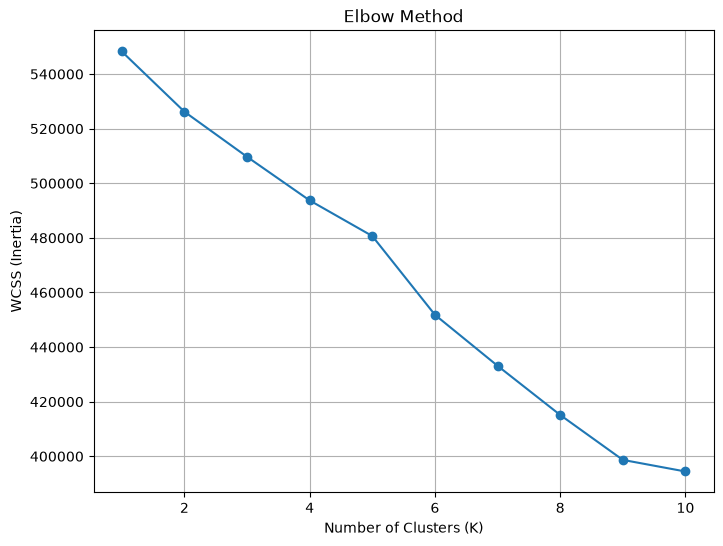

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()

Retrain with the optimal k=4

In [5]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)
clusters = kmeans.labels_
df["Cluster"] = clusters

Silhouette Score

In [6]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans.labels_)
print("Silhouette Score :",kmeans_score)

Silhouette Score : 0.11065731132182731


Compare Multiple K Values

In [7]:
scores = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, labels)

    scores.append(kmeans_score)
    print(f"K={k}, Silhouette Score = {kmeans_score:.4f}")

K=2, Silhouette Score = 0.0419
K=3, Silhouette Score = 0.0505
K=4, Silhouette Score = 0.0673
K=5, Silhouette Score = 0.0728
K=6, Silhouette Score = 0.1107
K=7, Silhouette Score = 0.1253
K=8, Silhouette Score = 0.1365
K=9, Silhouette Score = 0.1399
K=10, Silhouette Score = 0.1247


PCA Cluster Visualization

In [8]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

x_pca = pca.fit_transform(X_scaled)
print(x_pca.shape)

#Data Frame creation
pca_df = pd.DataFrame(x_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = kmeans.labels_

(17686, 2)


Plot Cluster

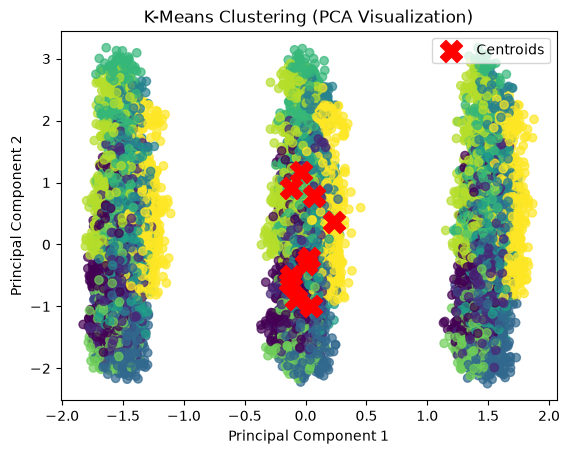

In [10]:
import matplotlib.pyplot as plt

centroids = pca.transform(kmeans.cluster_centers_)

plt.Figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
),

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
#plt.colorbar(scatter, label="cluster")

plt.legend()
plt.show()

Hierarchical Clustering

In [11]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hc_label = hc.fit_predict(X_scaled)
df["HC_Cluster"] = hc_label

print(df["HC_Cluster"].value_counts())

HC_Cluster
0    12323
1     1406
2     1379
3     1362
4     1216
Name: count, dtype: int64


In [12]:
#Evalluate using Silhouette Score

from sklearn.metrics import silhouette_score
hc_score = silhouette_score(X_scaled, hc_label)
print("Hierarchical Clustering Silhouette Score:", hc_score)

Hierarchical Clustering Silhouette Score: 0.06016675636482281


Dendogram Ploting 

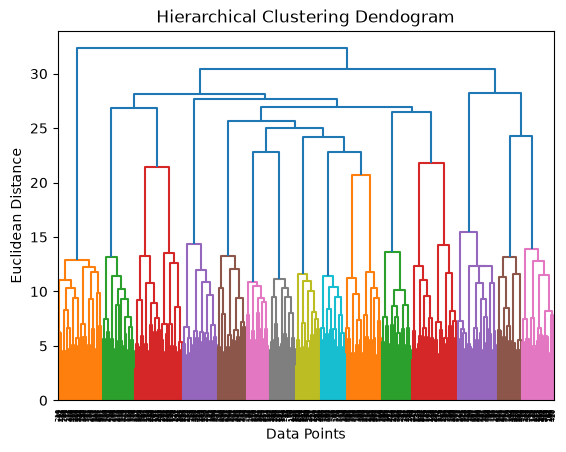

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Random choice from the Dataset
import numpy as np
np.random.seed(42)

indices = np.random.choice(X_scaled.shape[0], 500, replace=False)
X_sample = X_scaled[indices]

#Linkage matrix creation
linkage_matrix = linkage(X_sample, method="ward")

#Plotting
plt.Figure(figsize=(15,6))

dendrogram(
    linkage_matrix,
    truncate_mode=None
)

plt.title("Hierarchical Clustering Dendogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

DBSCAN : Density Based Spatial Clustering of Application with Noise

In [15]:
from sklearn.cluster import DBSCAN
db_scan = DBSCAN(
    eps = 3.5,
    min_samples=5
)

db_labels = db_scan.fit_predict(X_scaled)

#Add cluster label
df["DBSCAN_Cluster"] = db_labels

#Cluster distribution check
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     549
 0     191
 1     183
 2     170
 3     524
      ... 
 86    168
 87    172
 88    157
 89      2
 90      1
Name: count, Length: 92, dtype: int64


In [16]:
from sklearn.metrics import silhouette_score

dbscan_score = silhouette_score(X_scaled, db_labels)
print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.13241061854771707


Gaussian Mixture Model

In [17]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

# Train model
gmm.fit(X_scaled)

# Test model
gmm_lables = gmm.fit_predict(X_scaled)

# Add label to dataset
df["GMM_Cluster"] = gmm_lables

# Check cluster count
print(df["GMM_Cluster"].value_counts())

# View cluster Probabillities
probabilities = gmm.predict_proba(X_sample)
print(probabilities[:5])

print(probabilities.shape)

GMM_Cluster
2    5805
0    4057
1    3040
3    2960
4    1824
Name: count, dtype: int64
[[1.03589816e-10 3.05603962e-22 1.00000000e+00 1.48212782e-21
  0.00000000e+00]
 [1.00000000e+00 2.62480133e-16 0.00000000e+00 2.65670982e-16
  0.00000000e+00]
 [0.00000000e+00 8.27413281e-09 0.00000000e+00 9.99999992e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [1.00000000e+00 2.43124461e-16 0.00000000e+00 2.43449263e-16
  0.00000000e+00]]
(500, 5)


In [18]:
from sklearn.metrics import silhouette_score
gmm_score = silhouette_score(X_scaled, gmm_lables)
print("Gaussian Mixture Silhoette Score", gmm_score)

print(df["GMM_Cluster"].value_counts().sort_index())

print(gmm.means_)

Gaussian Mixture Silhoette Score 0.059934834392272075
GMM_Cluster
0    4057
1    3040
2    5805
3    2960
4    1824
Name: count, dtype: int64
[[-4.60698052e-03 -2.36544375e-03  1.04975950e-02 -1.05081672e-02
   1.61682878e-03 -2.13311250e-03 -2.48225809e-03 -2.62428959e-03
  -8.74088450e-03  1.89497882e-02  1.01473392e+00 -5.09130699e-01
   1.69590943e-01 -3.35569583e-01  1.45876847e-01  1.39682119e-01
  -3.39104415e-01  1.10863092e-01  1.26302300e-01 -3.28432188e-01
   1.39426027e-01  6.60128175e-01 -4.88150713e-03  5.21890253e-03
  -1.34351976e-02  1.77924396e-02  1.38377675e-02 -6.28843905e-03
  -3.36299139e-01 -3.36923726e-01 -2.44835576e-02]
 [-1.68473469e-02  1.09405596e-02 -1.00983220e-02  6.56309128e-03
  -1.26895119e-02 -8.97824606e-03 -2.96685438e-03  1.49435527e-02
   1.46375454e-02 -1.19695198e-02  2.62894541e-03 -1.79782137e-02
  -1.49557512e-01  1.41274294e+00 -1.46803736e-01 -1.44195863e-01
  -3.39104415e-01 -1.03099103e-01 -1.30803939e-01 -1.42018385e-01
  -1.30049400e-

GMM Visualization using PCA

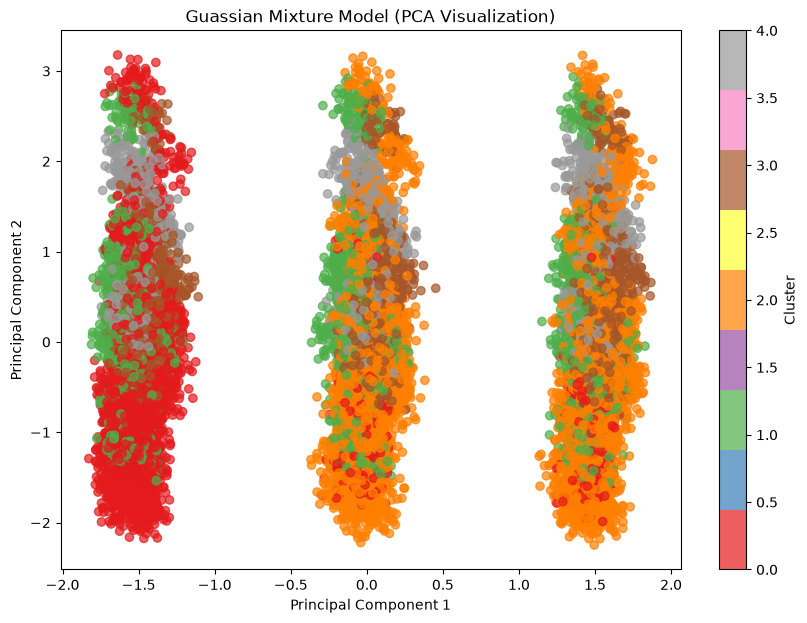

In [19]:
pca_df = pd.DataFrame(x_pca, columns=["PC1", "PC2"])
pca_df["GMM_Cluster"] = gmm_lables

#Plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c = pca_df["GMM_Cluster"],
    cmap="Set1",
    alpha=0.7
)

plt.title("Guassian Mixture Model (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.show()

Compare all Clustering Algorithm

In [20]:
comparison = pd.DataFrame({
    
    "Algorithm":[
        "K-Means",
        "Hierarchical",
        "Gaussian Mixture",
        "DBSCAN Score"
    ],
    "silhouette_score":[
        kmeans_score,
        hc_score,
        gmm_score,
        dbscan_score
    ]
})
comparison

,Algorithm,silhouette_score
0,K-Means,0.124708
1,Hierarchical,0.060167
2,Gaussian Mixture,0.059935
3,DBSCAN Score,0.132411
